In [ ]:
%pip uninstall -y onnxruntime onnxruntime-gpu
%pip install onnxruntime-gpu --extra-index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/ -q
%pip install pandas matplotlib pillow networkx insightface opencv-python torch_geometric torch torchvision -q

In [ ]:
# %pip uninstall -y onnxruntime onnxruntime-gpu
# %pip install onnxruntime-gpu --extra-index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/
%pip install pandas matplotlib pillow networkx onnxruntime multiprocess insightface opencv-python -q
%pip install ipywidgets torch_geometric torch torchvision jupyter-resource-usage -q
import torch
print(f"PyTorch version: {torch.__version__}")
%pip install --no-build-isolation torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.11.0+cpu.html -q

In [4]:
import pandas as pd


In [ ]:
import zipfile

file = 'public.zip'
with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
r_table = pd.read_csv('data/FIW_RIDs.csv')


def show_family_tree(fid: str):
    pass

   RID       Label
0    1       Child
1    2     Sibling
2    3  Grandchild
3    4      Parent
4    5      Spouse


  MID  1  2  3  4     Name Gender
0   1  0  5  4  4  madmoud      m
1   2  5  0  4  4    amina      f
2   3  1  1  0  2    tareq      m
3   4  1  1  2  0   yasser      m
{('1', '2'): 'Spouse', ('1', '3'): 'Parent', ('1', '4'): 'Parent', ('2', '1'): 'Spouse', ('2', '3'): 'Parent', ('2', '4'): 'Parent', ('3', '1'): 'Child', ('3', '2'): 'Child', ('3', '4'): 'Sibling', ('4', '1'): 'Child', ('4', '2'): 'Child', ('4', '3'): 'Sibling'}


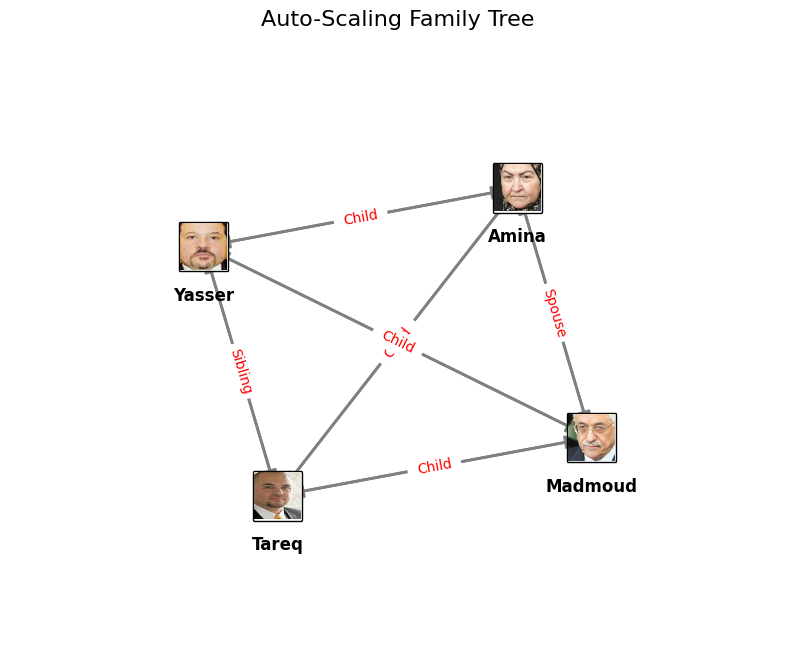

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import networkx as nx
from PIL import Image
import os
import glob

# --- Configuration ---
family_path = "data/FIDs/F0001/"
csv_path = os.path.join(family_path, "mid.csv")

# 1. Load the Data
df = pd.read_csv(csv_path, dtype={'MID': str})

# 2. Build the Family Graph
G = nx.DiGraph()
r_table = pd.read_csv('data/FIW_RIDs.csv')

for index, row in df.iterrows():
    mid = row['MID']
    name = row['Name']
    G.add_node(mid, name=name)

# Add Parent -> Child edges (RID = 4)
print(df)
dynamic_mids = [col for col in df.columns if str(col).isdigit()]
for index, row in df.iterrows():
    parent_mid = row['MID']
    for col_mid in dynamic_mids:
        if str(row[col_mid]) != '0':
            label = r_table.loc[r_table['RID'] == row[col_mid], 'Label'].values[0]
            G.add_edge(parent_mid, col_mid, label=label)

# 3. The Magic Function: Automatic Tree Layout
def get_tree_pos(graph):
    """Calculates X, Y coordinates to form a top-down hierarchy."""
    pos = {}
    
    # Find the "roots" of the tree (people with no parents listed in the graph)
    roots = [n for n, d in graph.in_degree() if d == 0]
    
    # Calculate which "generation" (level) each person belongs to
    levels = {}
    for node in graph.nodes():
        level = 0
        for root in roots:
            if nx.has_path(graph, root, node):
                path_length = nx.shortest_path_length(graph, root, node)
                if path_length > level:
                    level = path_length
        levels[node] = level
        
    # Count how many people are in each generation so we can space them evenly
    level_counts = {}
    for node, level in levels.items():
        level_counts[level] = level_counts.get(level, 0) + 1
        
    current_x = {level: 0 for level in level_counts}
    
    # Assign the final X and Y coordinates
    for node, level in levels.items():
        y = -level  # Move down the Y-axis for each new generation
        
        # Center the nodes on the X-axis for this generation
        total_in_level = level_counts[level]
        x = current_x[level] - (total_in_level - 1) / 2.0 
        current_x[level] += 1
        
        pos[node] = (x, y)
        
    return pos

# Generate the automatic layout!
pos = nx.spring_layout(G) 
# 4. Setup Canvas
# We scale the figure size based on the number of people so it doesn't get cramped
fig_width = max(10, len(G.nodes) * 1.5) 
fig, ax = plt.subplots(figsize=(fig_width, 8))
ax.axis('off')

# Draw lines
nx.draw_networkx_edges(G, pos, ax=ax,  arrows=True, arrowsize=20, edge_color="gray", width=2)

# 5. Image Fetching Function
def get_first_face_image(mid, zoom=0.15):
    folder_path = os.path.join(family_path, f"MID{mid}")
    search_pattern = os.path.join(folder_path, "*.*")
    image_files = [f for f in glob.glob(search_pattern) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        try:
            img = Image.open(image_files[0])
            return OffsetImage(img, zoom=zoom)
        except Exception as e:
            pass
            
    # Return a gray placeholder if no image exists
    return OffsetImage(Image.new('RGBA', (100, 100), (200, 200, 200, 255)))

# 6. Draw Images and Labels
for node in G.nodes():
    x, y = pos[node]
    imagebox = get_first_face_image(node)
    
    ab = AnnotationBbox(imagebox, (x, y), frameon=True, bboxprops=dict(edgecolor='black', boxstyle="round,pad=0.1"))
    ax.add_artist(ab)
    
    person_name = G.nodes[node]['name']
    plt.text(x, y - 0.35, person_name.capitalize(), horizontalalignment='center', fontsize=12, fontweight='bold')

# Automatically adjust the viewing window to fit all the new nodes
padding = 1.0
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
ax.set_ylim(min(all_y) - padding, max(all_y) + padding)

edge_labels = nx.get_edge_attributes(G, 'label')
print(edge_labels)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Auto-Scaling Family Tree", fontsize=16)
plt.show()

In [ ]:
import os
def show_dataset_info(path):
    families = {}
    families_stats = {}
    total_images = 0
    total_families = 0
    total_people = 0
    for r, dirs, files in os.walk(path):
        if r == "data/FIDs/" or r == "data/FIDs-features/" or r == "data/fiw_embeddings/":
            for d in dirs:
                families[d] = []
                families_stats[d] = {"count": 0}
                total_families += 1
        else:
            for f in files:
                if f.endswith(('.png', '.jpg', '.jpeg', '.pkl')):
                    total_images += 1
                    total_people += 1
                    # print(r)
                    family_id = list(filter(lambda x: "F" in x and "FIDs" not in x, r.split("/")))[0]
                    if family_id not in families:
                        families[family_id] = []
                        families_stats[family_id] = {"count": 0}
                    families[family_id].append(f)
                    families_stats[family_id]["count"] += 1
    return  families, families_stats, total_families, total_images, total_people

families, families_stats, total_families, total_images, total_people = show_dataset_info("data/FIDs/")
print(f"Total Families: {total_families}")
print(f"Total Images: {total_images}")
print(f"Total People: {total_people}")

families, families_stats, total_families, total_images, total_people = show_dataset_info("data/fiw_embeddings/")
print(f"Total Families: {total_families}")
print(f"Total Images: {total_images}")
print(f"Total People: {total_people}")




Total Families: 980
Total Images: 58572
Total Families: 980
Total Images: 40465


In [ ]:
import os
import multiprocessing as mp
from tqdm.auto import tqdm
import numpy as np
import cv2
import pickle

# Import our helpers
from fiw_processor import disk_writer_worker, get_face_app


def get_embedding_from_crop(rec_model, face_crop):
    img_resized = cv2.resize(face_crop, (112, 112))
    feat = rec_model.get_feat(img_resized)
    norm = np.linalg.norm(feat)
    embedding = feat / norm
    return embedding

def pad_image(img, pad_size=50):
    return cv2.copyMakeBorder(
        img, 
        pad_size, pad_size, pad_size, pad_size, 
        cv2.BORDER_CONSTANT, 
        value=[0, 0, 0]
    )

def run_preprocessing(root_dir, output_path):
    # Setup Multiprocessing
    manager = mp.Manager()
    write_queue = manager.Queue(maxsize=1000)
    
    # Start the writer process
    writer_process = mp.Process(target=disk_writer_worker, args=(write_queue,))
    writer_process.start()

    # Initialize ArcFace
    app = get_face_app()
    
    families = [f for f in os.listdir(root_dir) if f.startswith('F')]
    
    try:
        for family in tqdm(families, desc="Families"):
            fam_source = os.path.join(root_dir, family)
            fam_out = os.path.join(output_path, family)
            
            for person in os.listdir(fam_source):
                # print(f"Processing {family} - {person}")
                person_source = os.path.join(fam_source, person)
                person_out = os.path.join(fam_out, person)
                if not os.path.isdir(person_source): continue
                
                all_person_embeds = []
                for img_name in os.listdir(person_source):
                    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')): continue
                    
                    img_path = os.path.join(person_source, img_name)
                    pkl_out = os.path.join(person_out, os.path.splitext(img_name)[0] + ".pkl")

                    img = cv2.imread(img_path)
                    if img is None:
                        print("Image not found or unreadable:", img_path) 
                        continue
                    img = pad_image(img, pad_size=50)
                    faces = get_embedding_from_crop(app.models['recognition'], img)
                    if faces is not None:
                        embed = faces
                        all_person_embeds.append(embed)
                        write_queue.put((pkl_out, embed))
                    else:
                        print("No face generated for:", img_path)

                if all_person_embeds:
                    master_path = os.path.join(person_out, "mean_embedding.pkl")
                    write_queue.put((master_path, np.mean(all_person_embeds, axis=0)))

    finally:
        # Graceful shutdown
        write_queue.put(None)
        writer_process.join()
        print(f"✅ Process complete. Check: {output_path}")


    
# Run it
# main_path = 'drive/MyDrive/'
main_path = ""
# run_preprocessing(f'{main_path}data/FIDs', f'{main_path}data/fiw_embeddings')
# EXECUTE
run_preprocessing(root_dir=f'{main_path}data/FIDs', output_path=f'{main_path}data/fiw_embeddings')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
import pandas as pd
import torch
import pickle
import numpy as np
from torch_geometric.data import Data

class FIWGraphBuilder:
    def __init__(self, metadata_root="data/FIDs", embeddings_root="data/fiw_embeddings", num_relations=10):
        self.metadata_root = metadata_root   # Folder containing FIDs/mid.csv
        self.embeddings_root = embeddings_root # Folder containing FIDs/MIDx/*.pkl
        self.num_relations = num_relations
        
        self.node_features = []
        self.node_to_idx = {}
        self.edge_index = []
        self.edge_attr = []

    def build(self):
        # 1. Get all Family IDs present in the metadata folder
        fids = [f for f in os.listdir(self.metadata_root) if f.startswith('F')]
        global_idx = 0

        for fid in fids:
            # Paths for this specific family
            meta_fid_path = os.path.join(self.metadata_root, fid)
            embed_fid_path = os.path.join(self.embeddings_root, fid)
            csv_path = os.path.join(meta_fid_path, 'mid.csv')
            
            if not os.path.exists(csv_path):
                continue

            mid_df = pd.read_csv(csv_path)
            family_nodes = {} # Local map for this family

            # 2. Process Nodes: Match CSV MID to Embedding Folder
            for _, row in mid_df.iterrows():
                mid_val = str(int(row['MID']))
                
                # Construct path to the pre-processed master embedding
                # Assuming folder is MID1, MID2, etc.
                feat_path = os.path.join(embed_fid_path, f"MID{mid_val}", "mean_embedding.pkl")
                
                if os.path.exists(feat_path):
                    with open(feat_path, 'rb') as f:
                        self.node_features.append(pickle.load(f))
                    
                    self.node_to_idx[f"{fid}/{mid_val}"] = global_idx
                    family_nodes[mid_val] = global_idx
                    global_idx += 1

            # 3. Process Edges: Use the RID columns (1, 2, 3, 4...)
            mid_cols = [col for col in mid_df.columns if col.isdigit()]
            
            for _, row in mid_df.iterrows():
                src_mid = str(int(row['MID']))
                if src_mid not in family_nodes: continue
                
                for dst_mid in mid_cols:
                    rid = int(row[dst_mid])
                    
                    # 0=NA, 9=TBD. Skip these as they aren't valid kinship edges.
                    if rid in [0, 9] or dst_mid not in family_nodes:
                        continue
                    
                    # Add edge (Directed as per mid.csv)
                    self.edge_index.append([family_nodes[src_mid], family_nodes[dst_mid]])
                    
                    # One-hot encoding of the Relationship ID (RID)
                    attr = np.zeros(self.num_relations)
                    attr[rid] = 1.0
                    self.edge_attr.append(attr)

        # Final Tensor Conversion
        x = torch.tensor(np.array(self.node_features), dtype=torch.float)
        edge_index = torch.tensor(self.edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(np.array(self.edge_attr), dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

builder = FIWGraphBuilder(metadata_root='data/FIDs', embeddings_root='data/fiw_embeddings')
data = builder.build()
print(data)

Data(x=[5030, 1, 512], edge_index=[2, 19023], edge_attr=[19023, 10])


In [14]:
from torch_geometric.loader import NeighborLoader
loader = NeighborLoader(
    data,
    num_neighbors=[5, 5, 3, 2], # Sample 10 neighbors at 1-hop, 5 at 2-hops
    batch_size=128,
    shuffle=True
)
print(next(iter(loader)))

Data(x=[714, 1, 512], edge_index=[2, 2492], edge_attr=[2492, 10], n_id=[714], e_id=[2492], input_id=[128], batch_size=128)
